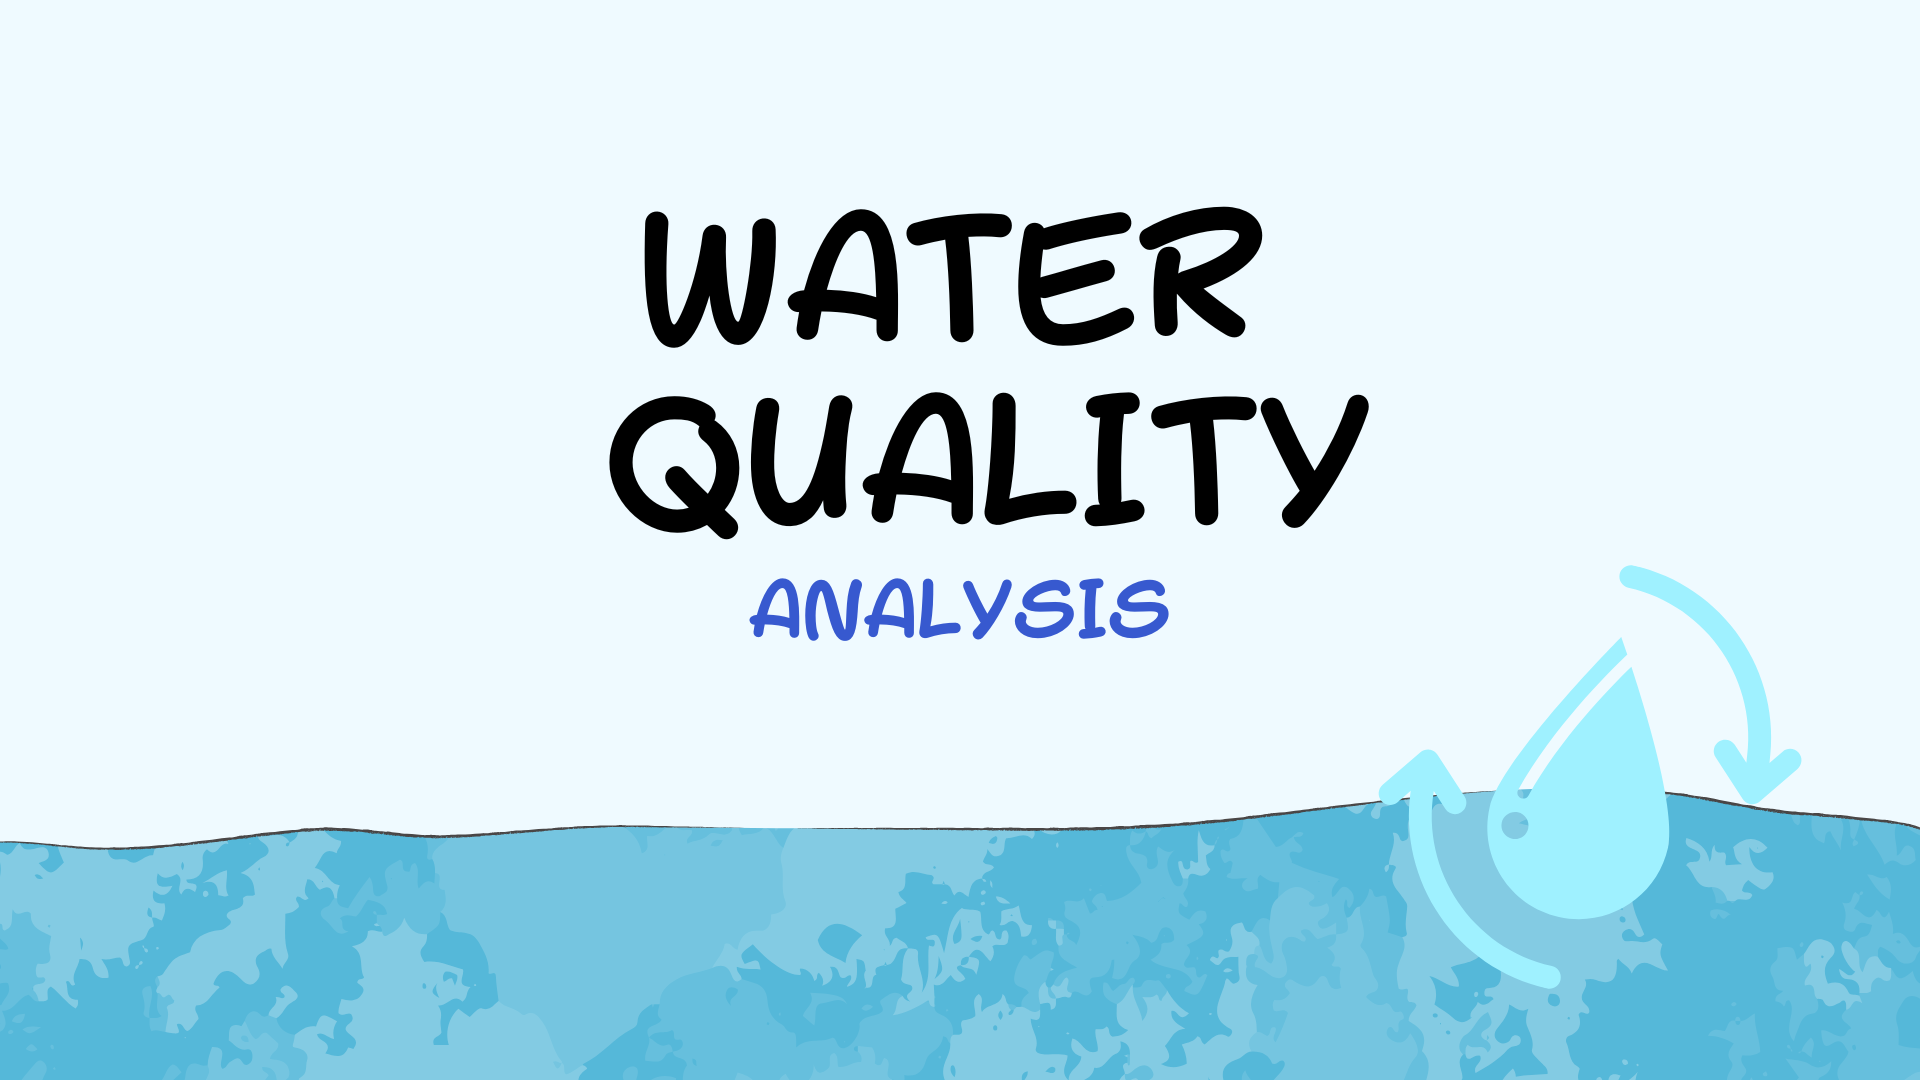

In [59]:
from IPython.display import Image, display

display(Image(filename='./assets/header.png'))  


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import seaborn as sns
import pandas as pd
import numpy as np

In [15]:
water_df = pd.read_csv('./data/water_potability.csv')

In [49]:
print('****'*10)
print(f'Dataframe has {water_df.shape[0]} Rows, {water_df.shape[1]} Columns')
print('****'*10)

water_df.head().style.set_properties(**{'background-color': '#A2DBFA',
                                    'color': 'black',
                                    'border': '1.5px  solid black'}).bar(color='#F3F1F5', 
                                                                         vmin=100_000, 
                                                                         subset=['Potability'])

****************************************
Dataframe has 3276 Rows, 10 Columns
****************************************


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,nan,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,nan,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,nan,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [40]:
water_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [41]:
water_df.describe().T.style.bar(subset=['mean'], color='#E68193')\
                            .background_gradient(subset=['std'], cmap='mako_r')\
                             .background_gradient(subset=['50%'], cmap='mako')

,count,mean,std,min,25%,50%,75%,max
ph,2785.000000,7.080795,1.594320,0.000000,6.093092,7.036752,8.062066,14.000000
Hardness,3276.000000,196.369496,32.879761,47.432000,176.850538,196.967627,216.667456,323.124000
Solids,3276.000000,22014.092526,8768.570828,320.942611,15666.690297,20927.833607,27332.762127,61227.196008
Chloramines,3276.000000,7.122277,1.583085,0.352000,6.127421,7.130299,8.114887,13.127000
Sulfate,2495.000000,333.775777,41.416840,129.000000,307.699498,333.073546,359.950170,481.030642
Conductivity,3276.000000,426.205111,80.824064,181.483754,365.734414,421.884968,481.792304,753.342620
Organic_carbon,3276.000000,14.284970,3.308162,2.200000,12.065801,14.218338,16.557652,28.300000
Trihalomethanes,3114.000000,66.396293,16.175008,0.738000,55.844536,66.622485,77.337473,124.000000
Turbidity,3276.000000,3.966786,0.780382,1.450000,3.439711,3.955028,4.500320,6.739000
Potability,3276.000000,0.390110,0.487849,0.000000,0.000000,0.000000,1.000000,1.000000


In [42]:
# Menampilkan jumlah nilai unik dalam dataset
print("\nJumlah Nilai Unik per Kolom:")
print(water_df.nunique())


Jumlah Nilai Unik per Kolom:
ph                 2785
Hardness           3276
Solids             3276
Chloramines        3276
Sulfate            2495
Conductivity       3276
Organic_carbon     3276
Trihalomethanes    3114
Turbidity          3276
Potability            2
dtype: int64


In [43]:
# Mengecek jumlah missing values
print("\nMissing Values dalam Dataset:")
print(water_df.isnull().sum())


Missing Values dalam Dataset:
ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64


Visualisasi data

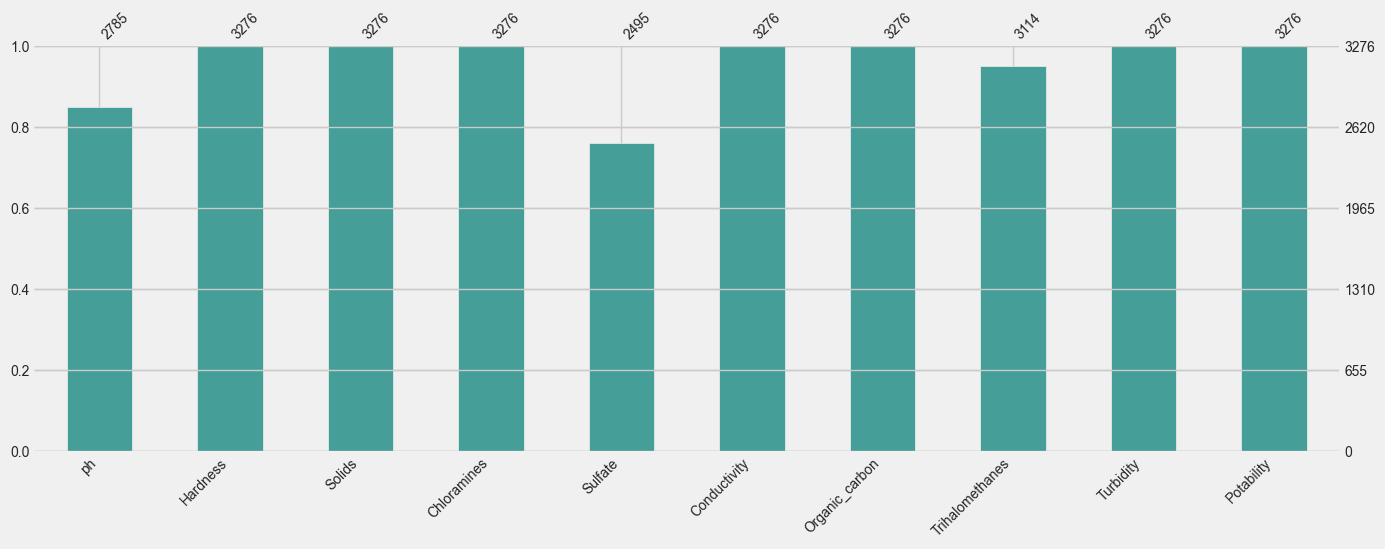

In [44]:
msno.bar(water_df,figsize=(15, 5),fontsize=10,color = '#459E97');

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_13164\805339094.py:7: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




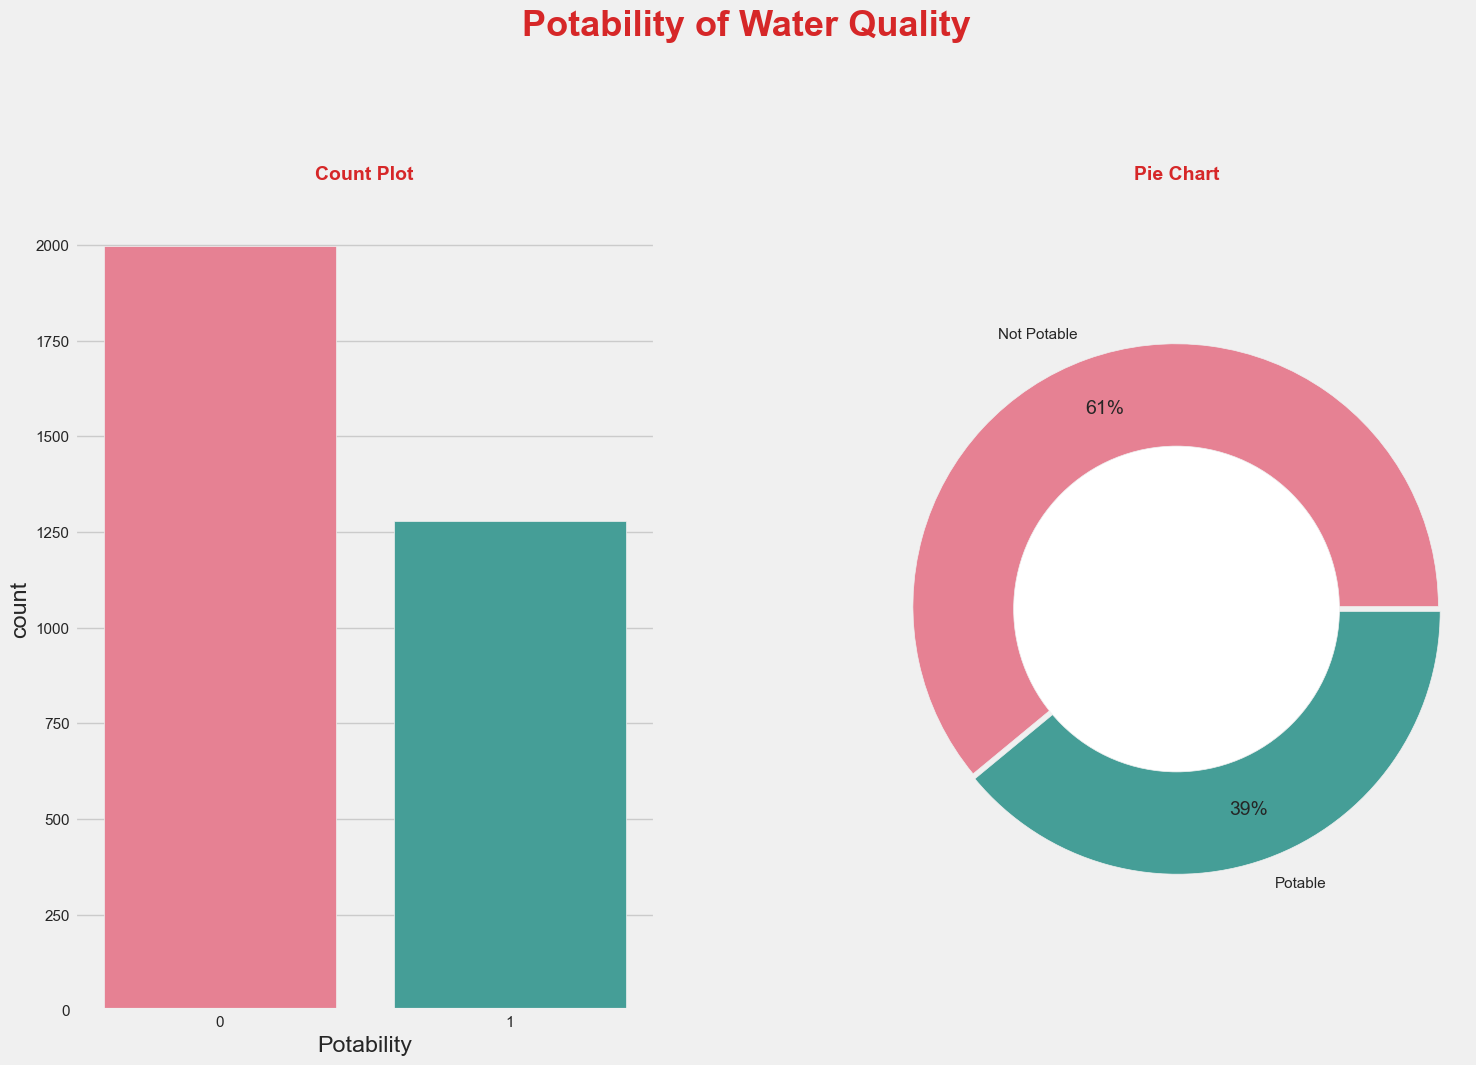

In [45]:
# Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 11))
fig.suptitle('Potability of Water Quality', size=26, color=theme[3], weight='bold')
axs = [ax1, ax2]

# Count Plot
sns.countplot(x='Potability', data=water_df, ax=ax1, palette='husl', hue=None, legend=False)
ax1.set_title('Count Plot', size=14, color=theme[3], weight='bold', pad=20)

# Pie Chart (Doughnut)
names = ["Not Potable", "Potable"]
values = water_df['Potability'].value_counts().sort_index()
colors = ["#E68193", "#459E97"]
explode = (0.01, 0.01)

# Pie chart
ax2.pie(x=values, labels=names, colors=colors, autopct='%1.0f%%', pctdistance=0.8, explode=explode)

# Doughnut center
centre_circle = plt.Circle((0, 0), 0.62, fc='white')
ax2.add_artist(centre_circle)
ax2.axis('equal')
ax2.set_title('Pie Chart', size=14, color=theme[3], weight='bold', pad=20)

# Layout
plt.subplots_adjust(left=None, bottom=None, right=None, top=0.8, wspace=0.4, hspace=None)
plt.show()


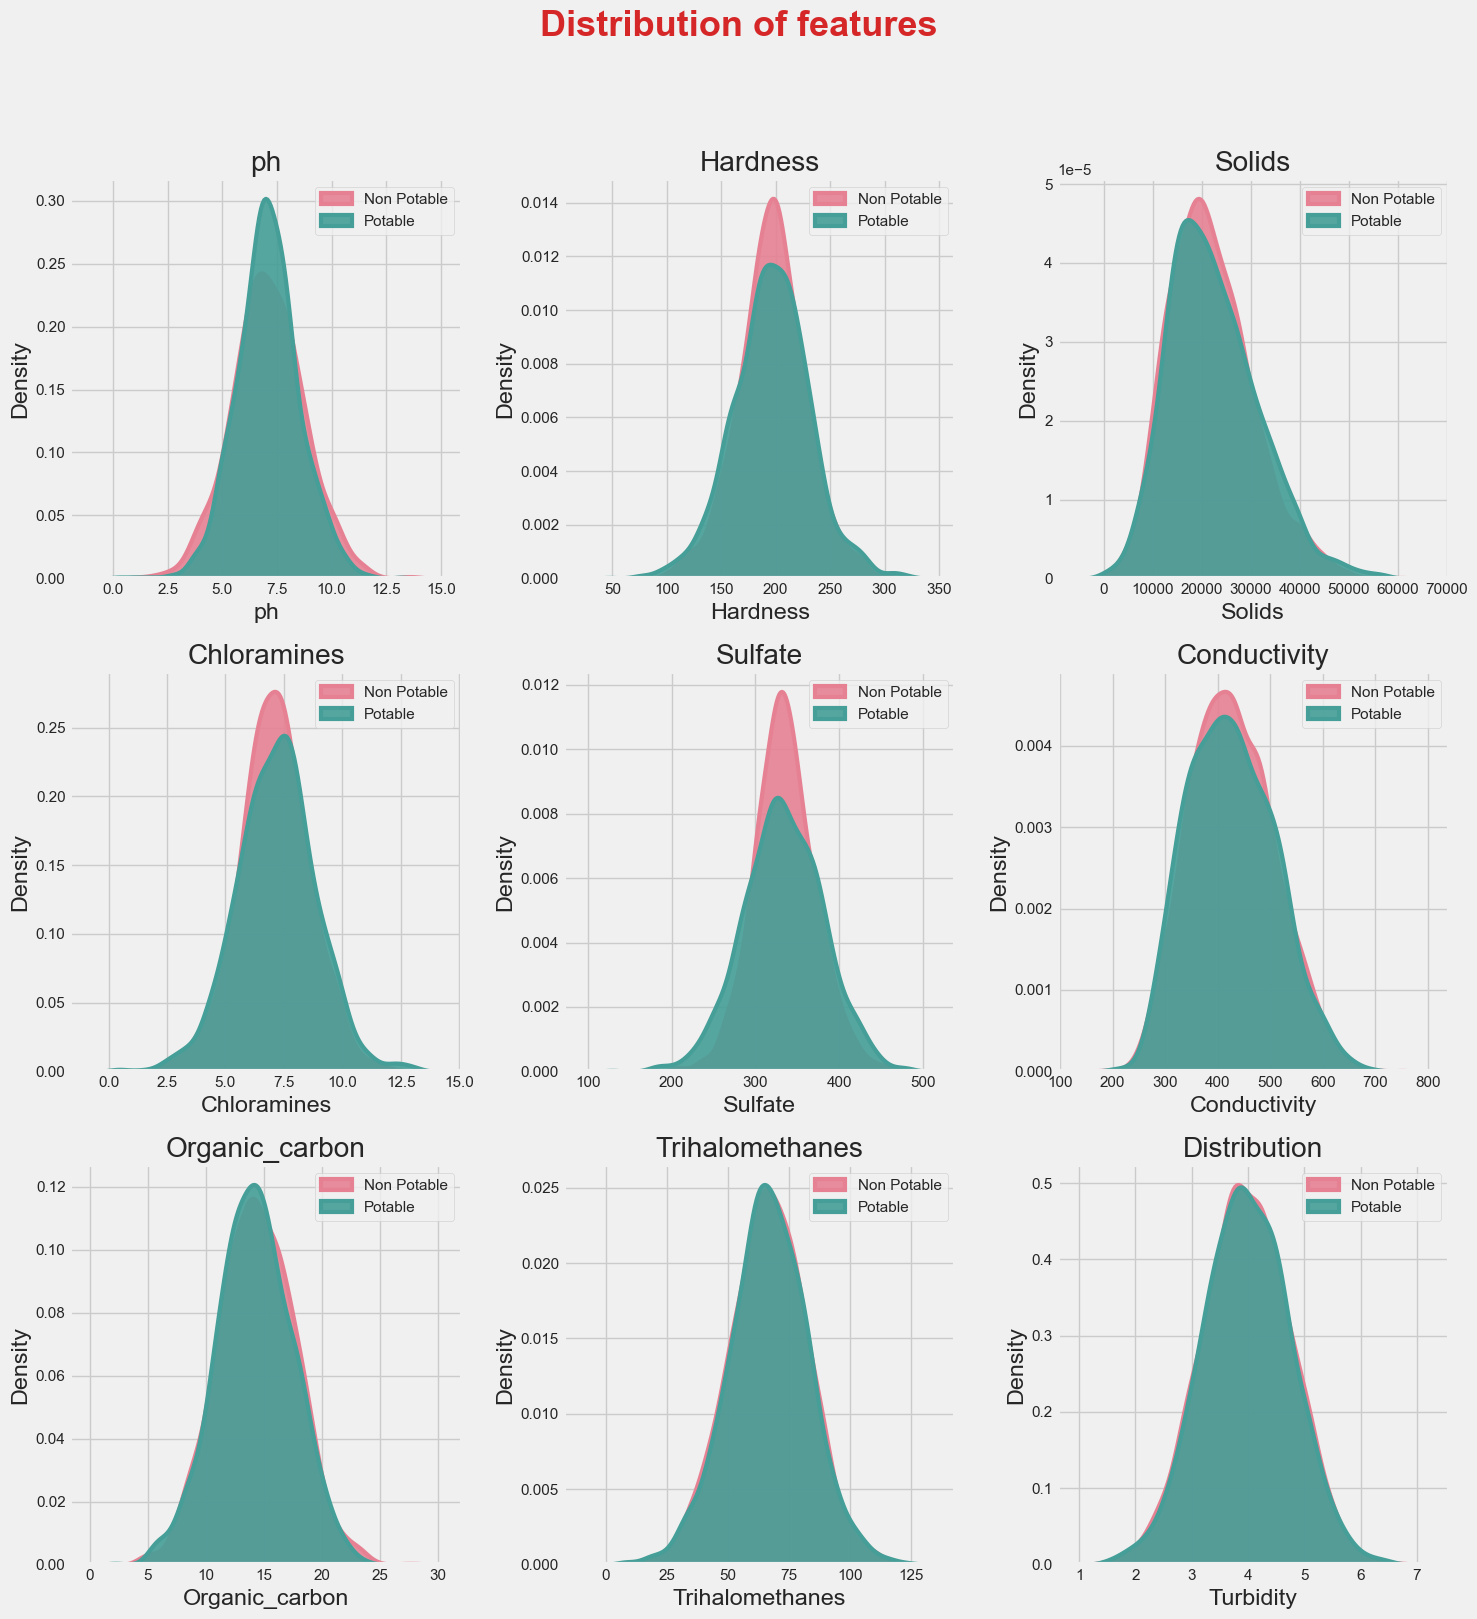

In [46]:
non_potable = water_df.query("Potability == 0")
potable = water_df.query("Potability == 1")

plt.figure(figsize = (15,15))
for ax, col in enumerate(water_df.columns[:9]):
    plt.subplot(3,3, ax + 1)
    plt.title(col)
    plotting = sns.kdeplot(x = non_potable[col], label = "Non Potable",fill=True, common_norm=False, color="#E68193",alpha=.9, linewidth=3)
    plotting = sns.kdeplot(x = potable[col], label = "Potable",fill=True, common_norm=False, color="#459E97",alpha=.9, linewidth=3)
    plt.legend()
plt.tight_layout()
plt.title('Distribution')
plotting.figure.suptitle(' Distribution of features ',y=1.08, size = 26, color = theme[3], weight='bold');

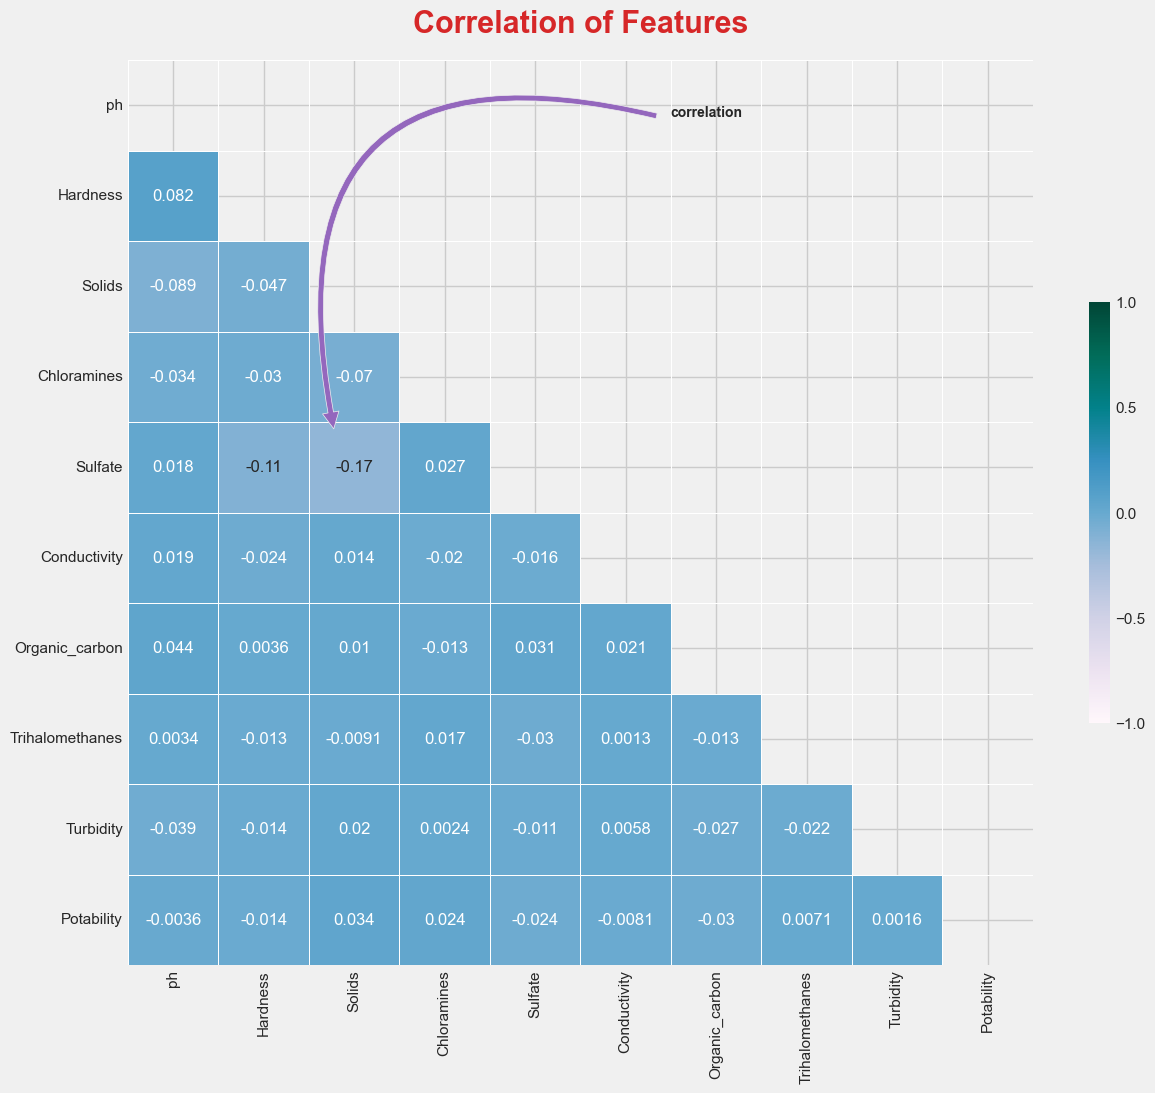

In [47]:
# Define theme colors if not already defined
theme = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', 
         '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

# Create correlation matrix mask
mask = np.zeros_like(water_df.corr(), dtype=bool)  # Changed from np.bool to bool
mask[np.triu_indices_from(mask)] = True

fig, ax = plt.subplots(figsize=(13, 13))

heatmap = sns.heatmap(water_df.corr(),
                      mask=mask,
                      square=True,
                      linewidths=.5,
                      cmap='PuBuGn',
                      cbar_kws={'shrink': .4, "ticks": [-1, -.5, 0, 0.5, 1]},
                      vmin=-1,
                      vmax=1,
                      annot=True,
                      annot_kws={"size": 12})

# Add column names as labels
ax.set_yticklabels(water_df.corr(), rotation=0)
ax.set_xticklabels(water_df.corr())

sns.set_style({'xtick.bottom': True}, {'ytick.left': True})

# Add correlation annotation
ax.annotate('correlation',
           fontsize=10,
           fontweight='bold',
           xy=(2.3, 4.2),
           xycoords='data',
           xytext=(0.6, 0.95),
           textcoords='axes fraction',
           arrowprops=dict(
               facecolor=theme[4],
               shrink=0.025,
               connectionstyle='arc3, rad=0.80'),
           horizontalalignment='left',
           verticalalignment='top')

ax.set_title('Correlation of Features', size=22, color=theme[3], weight='bold', pad=20)

plt.show()

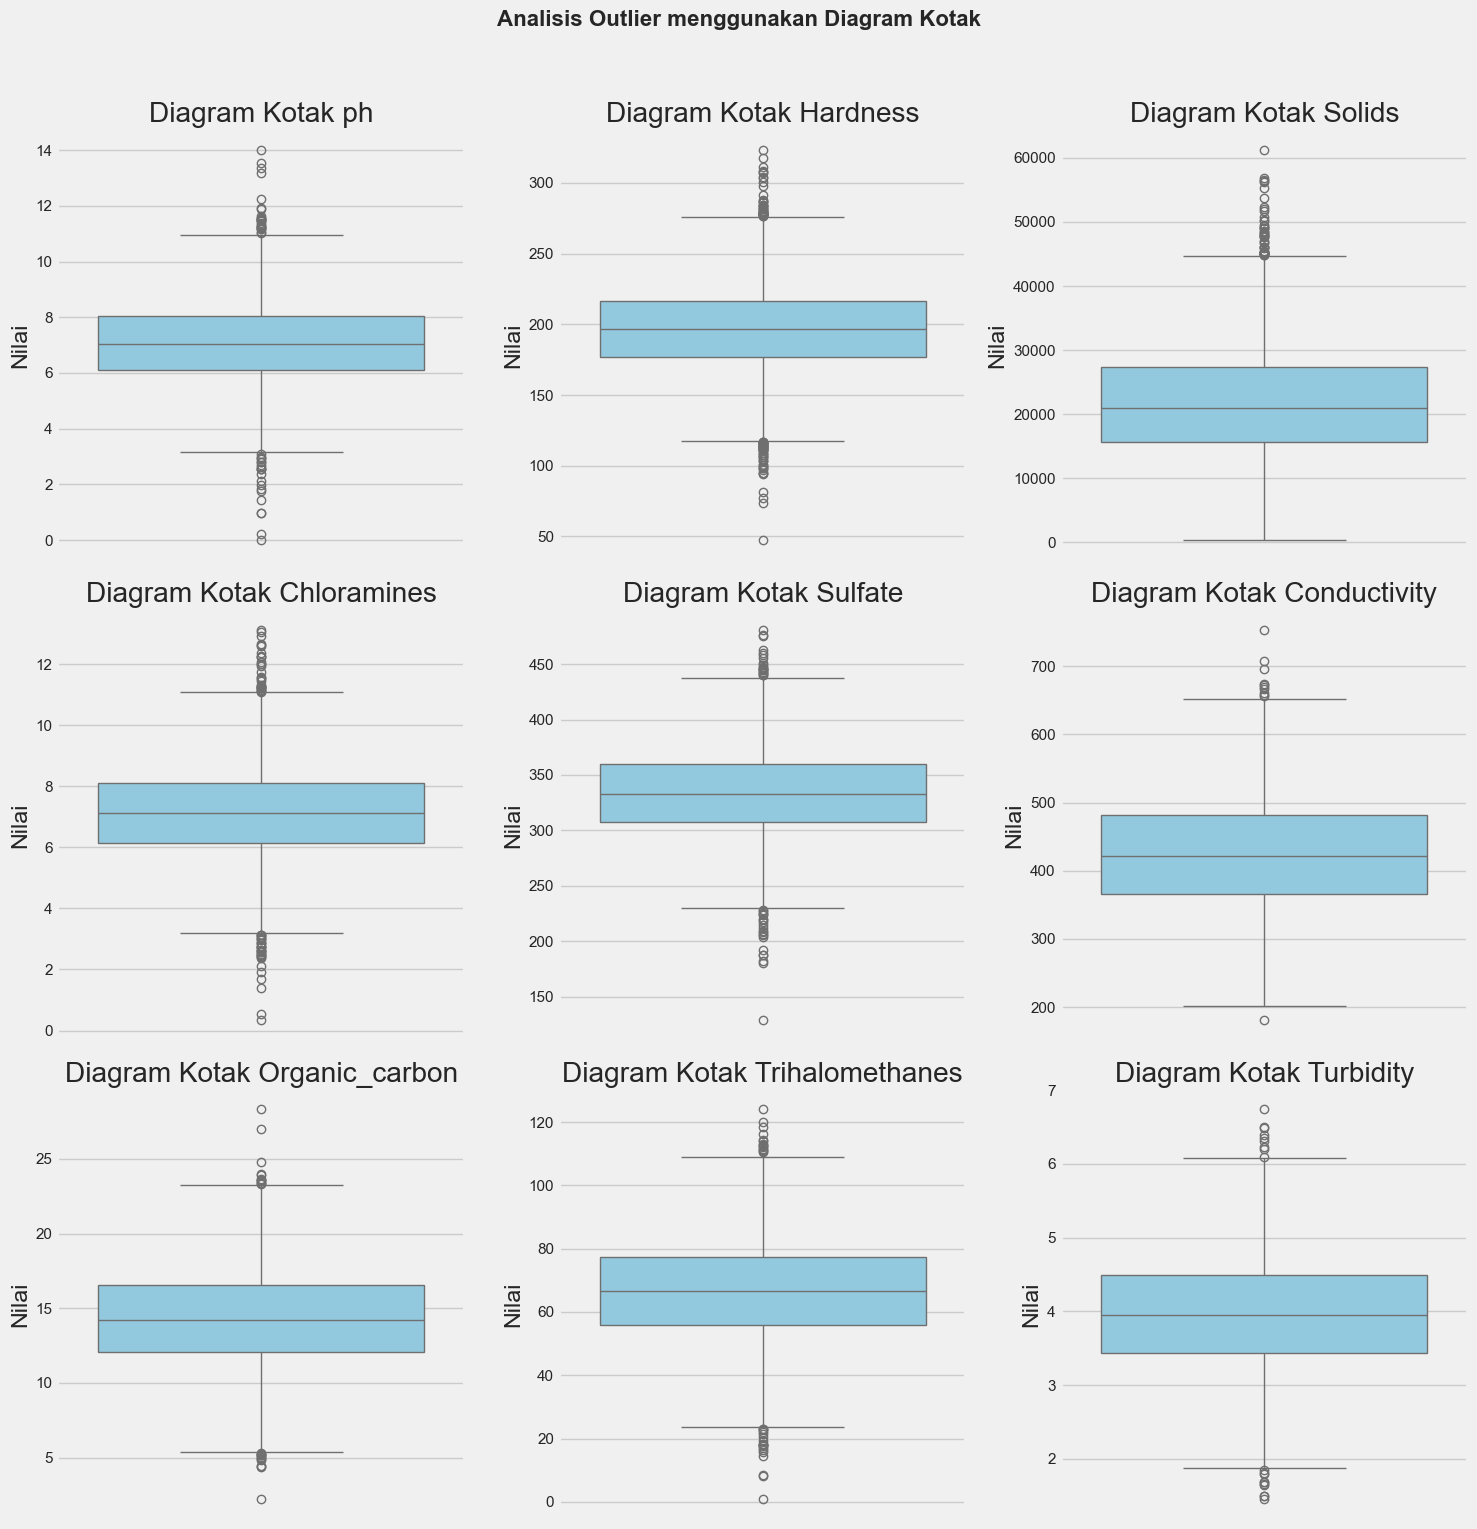


Ringkasan Jumlah Pencilan (Outlier) per Kolom:
Kolom ph: 46 pencilan
Kolom Hardness: 83 pencilan
Kolom Solids: 47 pencilan
Kolom Chloramines: 61 pencilan
Kolom Sulfate: 41 pencilan
Kolom Conductivity: 11 pencilan
Kolom Organic_carbon: 25 pencilan
Kolom Trihalomethanes: 33 pencilan
Kolom Turbidity: 19 pencilan
Kolom Potability: 0 pencilan


In [58]:
# Membuat subplot untuk setiap fitur
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
axes = axes.ravel()

for idx, col in enumerate(water_df.columns[:-1]):  # Mengecualikan variabel target
    sns.boxplot(data=water_df, y=col, ax=axes[idx], color='skyblue')
    axes[idx].set_title(f'Diagram Kotak {col}')
    axes[idx].set_ylabel('Nilai')  # Menambahkan label sumbu y
    
plt.suptitle('Analisis Outlier menggunakan Diagram Kotak', 
             size=16, 
             weight='bold',
             y=1.02)
plt.tight_layout()
plt.show()

# Mencetak detail outlier
print("\nRingkasan Jumlah Pencilan (Outlier) per Kolom:")
for col, count in outliers.items():
    print(f"Kolom {col}: {count} pencilan")